# What is the most optimal skill to learn for Data Engineers?

### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DE_US = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')]

In [3]:
df_DE_US = df_DE_US.dropna(subset='salary_year_avg')

df_DE_US_exploded = df_DE_US.explode('job_skills')

df_DE_US_exploded[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
92,120000.0,sql
92,120000.0,python
146,129500.0,golang
146,129500.0,scala
146,129500.0,python


In [4]:
df_DE_skills = df_DE_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DE_skills = df_DE_skills.rename(columns={'count': 'skill_count', 'median':'median_salary'})

DE_job_count = len(df_DE_US)

df_DE_skills['skill_percent'] = df_DE_skills['skill_count'] / DE_job_count * 100

skill_percent = 15

df_DE_skills_high_demand = df_DE_skills[df_DE_skills['skill_percent'] > skill_percent]

df_DE_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2110,125000.00000,72.384220
python,2007,127794.50000,68.850772
aws,1313,131000.00000,45.042882
spark,968,137410.15625,33.207547
azure,961,125000.00000,32.967410
snowflake,765,130700.00000,26.243568
java,732,137000.00000,25.111492
kafka,536,145000.00000,18.387650
nosql,519,140000.00000,17.804460


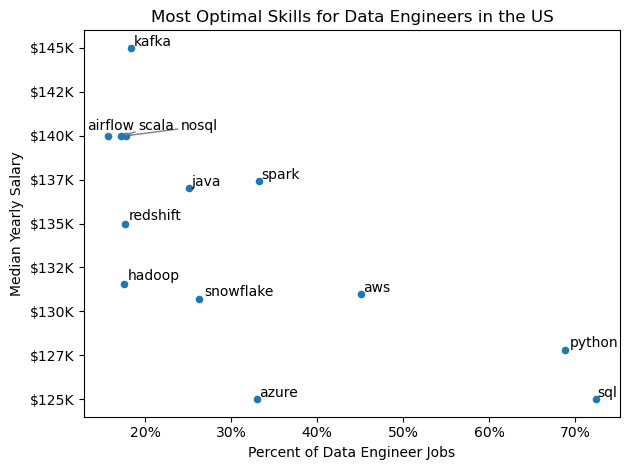

In [5]:
from adjustText import adjust_text

df_DE_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DE_skills_high_demand.index):
    texts.append(plt.text(df_DE_skills_high_demand['skill_percent'].iloc[i], df_DE_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Engineer Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Engineers in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
# Adjust layout and display plot 
plt.tight_layout()
plt.show()

In [6]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dict (dict which was already contained in str)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# remove duplicates by converting values to set them back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['msaccess',
  'spreadsheet',
  'tableau',
  'powerpoint',
  'spss',
  'alteryx',
  'nuix',
  'looker',
  'power bi',
  'sheets',
  'microstrategy',
  'datarobot',
  'excel',
  'sharepoint',
  'visio',
  'ms access',
  'ssis',
  'ssrs',
  'qlik',
  'word',
  'cognos',
  'esquisse',
  'dax',
  'powerbi',
  'splunk',
  'sap',
  'sas',
  'outlook'],
 'programming': ['no-sql',
  'c#',
  'kotlin',
  'powershell',
  'perl',
  'bash',
  'ruby',
  'scala',
  'fortran',
  'matlab',
  'cobol',
  'visualbasic',
  'css',
  'java',
  'c++',
  'lua',
  'erlang',
  'javascript',
  'html',
  'ocaml',
  'mongo',
  'delphi',
  'rust',
  'sql',
  'solidity',
  'python',
  'crystal',
  'vb.net',
  'objective-c',
  'typescript',
  'mongodb',
  't-sql',
  'julia',
  'groovy',
  'r',
  'clojure',
  'lisp',
  'golang',
  'visual basic',
  'swift',
  'f#',
  'assembly',
  'dart',
  'elixir',
  'pascal',
  'shell',
  'haskell',
  'go',
  'nosql',
  'php',
  'apl',
  'sass',
  'sas',
  'c',
  '

In [7]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,msaccess
0,analyst_tools,spreadsheet
0,analyst_tools,tableau
0,analyst_tools,powerpoint
0,analyst_tools,spss
...,...,...
9,sync,google chat
9,sync,webex
9,sync,ringcentral
9,sync,wire


In [8]:
df_plot = df_DE_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

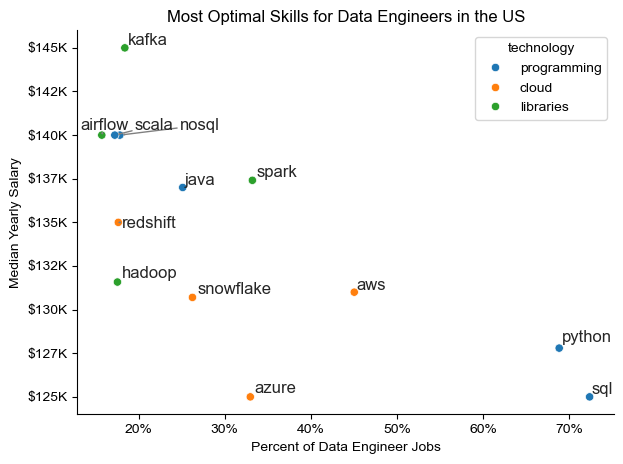

In [9]:
from adjustText import adjust_text

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data=df_plot, 
    x='skill_percent', 
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DE_skills_high_demand.index):
    texts.append(plt.text(df_DE_skills_high_demand['skill_percent'].iloc[i], df_DE_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Engineer Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Engineers in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
# Adjust layout and display plot 
plt.tight_layout()
plt.show()